In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.table as table
import pandas as pd

from torch.utils.data import DataLoader
import torch

In [2]:
# Load Preprocessed Data (lemmatization, stopwords, punctuation, etc.)
data = np.genfromtxt('./data/train_data.csv', delimiter='\t', dtype=None, encoding=None, skip_header=1)

reviews, sentiments = zip(*data)

data.tolist()[:5]

[('wow loved place', 1),
 ('crust good', 0),
 ('tasty texture wa nasty', 0),
 ('stopped late may bank holiday rick steve recommendation loved', 1),
 ('selection menu wa great price', 1)]

In [3]:
reviews = list(reviews)

In [4]:
# Vectorization (the review comments)
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1500, min_df=3, max_df=0.6)
vectorized_reviews = vectorizer.fit_transform(reviews).toarray()

In [5]:
vectorized_data = list(zip(vectorized_reviews, sentiments))

In [6]:
from src.Dataset import MyDataset

train_set = MyDataset(vectorized_data, transform=torch.from_numpy)

train_loader = DataLoader(train_set, batch_size=4, shuffle=True, num_workers=1)

In [7]:
train_set[0][0].shape

torch.Size([368])

In [8]:
from src.Net import Net

net = Net()

In [9]:
import torch.optim as optim
import time

start = time.time()

criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

epochs = 20
mini_batch_size = 20

lossArr = []
running_loss = 0.0


for epoch in range(epochs):
        for i, data in enumerate(train_loader, 0):
            inputs, labels = data
            
            labels = labels.long()
    
            optimizer.zero_grad()
    
            outputs = net(inputs.float())
            
            loss = criterion(outputs, labels)
            
            loss.backward()
            
            optimizer.step()
            
            running_loss += loss.item()
            
            if i % mini_batch_size == mini_batch_size - 1:
                
                print('[%d, %5d] loss: %.3f' % (epoch + 1, i + 1, loss.item()))
                
                lossArr.append(running_loss/mini_batch_size)
                
                running_loss = 0.0

end = time.time()

print(f"Finished Training, time: {end - start} sec...")

[1,    20] loss: 0.691
[1,    40] loss: 0.687
[1,    60] loss: 0.673
[1,    80] loss: 0.665
[1,   100] loss: 0.698
[1,   120] loss: 0.655
[1,   140] loss: 0.743
[1,   160] loss: 0.808
[1,   180] loss: 0.754
[1,   200] loss: 0.651
[2,    20] loss: 0.644
[2,    40] loss: 0.816
[2,    60] loss: 0.574
[2,    80] loss: 0.631
[2,   100] loss: 0.631
[2,   120] loss: 0.634
[2,   140] loss: 0.773
[2,   160] loss: 0.700
[2,   180] loss: 0.645
[2,   200] loss: 0.646
[3,    20] loss: 0.757
[3,    40] loss: 0.641
[3,    60] loss: 0.702
[3,    80] loss: 0.638
[3,   100] loss: 0.643
[3,   120] loss: 0.584
[3,   140] loss: 0.639
[3,   160] loss: 0.636
[3,   180] loss: 0.701
[3,   200] loss: 0.699
[4,    20] loss: 0.700
[4,    40] loss: 0.760
[4,    60] loss: 0.697
[4,    80] loss: 0.645
[4,   100] loss: 0.637
[4,   120] loss: 0.698
[4,   140] loss: 0.567
[4,   160] loss: 0.632
[4,   180] loss: 0.702
[4,   200] loss: 0.770
[5,    20] loss: 0.697
[5,    40] loss: 0.695
[5,    60] loss: 0.695
[5,    80] 

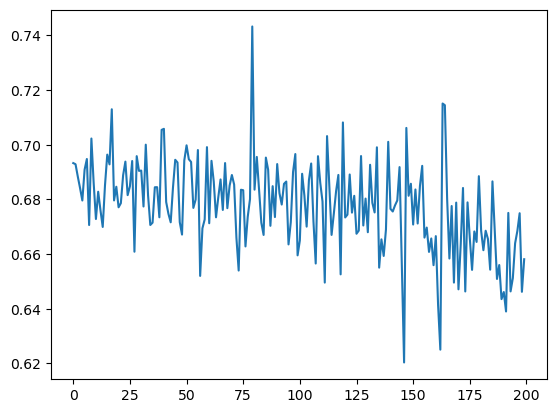

In [10]:
plt.plot(lossArr)

In [11]:
save_path = './models/model.pth'
torch.save(net.state_dict(), save_path)